In [ ]:
import json
import os
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch
import time
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import vertexai as vtx
from vertexai.generative_models import GenerativeModel
from google.api_core import exception

Load Documents

In [22]:
torch.cuda.empty_cache()

In [23]:
DATASET_PATH = "../Dataset"

def load_documents():
    docs = {}
    doc_dir = os.path.join(DATASET_PATH, "documents")
    
    for file in os.listdir(doc_dir):
        if file.endswith(".txt"):
            name = file.replace(".txt", "")
            file_path = os.path.join(doc_dir, file)
            with open(file_path, "r", encoding="utf-8") as f:
                docs[name] = f.read()
    return docs

def load_all_qa():
    all_qa = []
    qa_dir = os.path.join(DATASET_PATH, "qa")
    
    for file in os.listdir(qa_dir):
        if file.endswith(".json"):
            file_path = os.path.join(qa_dir, file)
            with open(file_path, "r", encoding="utf-8") as f:
                all_qa.extend(json.load(f))
    return all_qa

Load LLM models

In [24]:
PROJECT_ID = "gen-lang-client-0279093715"
LOCATION = "europe-west4"
vtx.init(project = PROJECT_ID, location = LOCATION)

In [ ]:
def load_model(model_name):
    model = GenerativeModel(model_name)
    return None, model


In [ ]:
GEMINI = "gemini-2.5-flash"
#QWEN = "Qwen/Qwen2.5-1.5B-Instruct"

Metric Utils

In [27]:
# Token Counter
def count_tokens(tokenizer, text):
    return len(tokenizer(text)["input_ids"])

In [28]:
# Exact Match
def exact_match(pred, gold):
    return int(pred.strip() == gold.strip())

In [ ]:
def generate(model, prompt):
    start_total = time.time()

    # Exponential Backoff for Gemini API
    for attempt in range(6):
        try:
            response = model.generate_content(
                prompt, 
                generation_config={"max_output_tokens": 300, "temperature": 0.0}
            )
            text = response.text
            
            usage = response.usage_metadata
            return {
                "text": text,
                "latency": time.time() - start_total,
                "prompt_tokens": usage.prompt_token_count,
                "output_tokens": usage.candidates_token_count
            }
            
        except exceptions.ResourceExhausted:
            wait_time = (2 ** attempt) + 5 
            print(f"429 Rate Limit Hit. Retrying in {wait_time}s...")
            time.sleep(wait_time)
        except Exception as e:
            print(f"Error: {e}")
            time.sleep(2)
            
    return None

In [ ]:
# def generate(model, tokenizer, prompt):

#     # Full Pipeline Timer
#     start_total = time.time()

#     if tokenizer is None:

#         response = model.generate_content(prompt, generation_config={"max_output_tokens": 300})
#         text = response.text

#         latency = time.time() - start_total
#         usage = response.usage_metadata

#         prompt_tokens_used = usage.prompt_token_count
#         output_tokens = usage.candidates_token_count
#         full_prompt_tokens = usage.total_token_count

#         return text, latency, full_prompt_tokens, prompt_tokens_used, output_tokens
#     else:
#         # Count tokens BEFORE truncation
#         full_prompt_tokens = len(tokenizer(prompt, add_special_tokens=False)["input_ids"])

#         # Tokenization with truncation for the model
#         inputs = tokenizer(
#             prompt,
#             return_tensors="pt",
#             truncation=True,
#             max_length= 12288
#         )

#         inputs = {k: v.to(model.device) for k, v in inputs.items()}

#         prompt_tokens_used = inputs["input_ids"].shape[1]

#         # Model generation
#         output = model.generate(**inputs, max_new_tokens=1024)

#         end_total = time.time()

#         # Decode output
#         text = tokenizer.decode(output[0], skip_special_tokens=True)

#         output_tokens = output.shape[-1]

#         # TRUE END-TO-END LATENCY
#         latency = end_total - start_total

#         return text, latency, full_prompt_tokens, prompt_tokens_used, output_tokens

In [30]:
# # Timed Generation
# def generate(model, tokenizer, prompt):
#     torch.cuda.empty_cache()
#     start = time.time()
#     inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(model.device)
    
#     device = next(model.parameters()).device
#     inputs = {k: v.to(device) for k, v in inputs.items()}

#     with torch.no_grad():
#         outputs = model.generate(
#             **inputs,
#             temperature=0.0,    
#             do_sample=False
#         )
#     end = time.time()

#     output_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

#     latency = end - start
#     input_tokens = inputs["input_ids"].shape[1]
#     output_tokens = outputs.shape[1] - input_tokens
#     torch.cuda.empty_cache()
#     return output_text, latency, input_tokens + output_tokens

LLM Systems

Prompt Only

In [ ]:
def run_prompt_only(model, tokenizer, docs, qa_data):
    results = []

    answers = []

    for item in qa_data:
        doc_text = docs[item["document"]]

        prompt = f"""
Extract the exact answer span from the document.

Document:
{doc_text}

Question:
{item["question"]}

Answer:
"""

        gen = generate(model, prompt)
        results.append({
            "qa_id": item["id"],
            "system": "Prompt-Only",
            "latency": gen["latency"],
            "prompt_tokens_full": gen["prompt_tokens"],
            "prompt_tokens_used": gen["prompt_tokens"],
            "output_tokens": gen["output_tokens"],
            "EM": exact_match(gen["text"], item["answer_text"])
        })

        answers.append({
            "qa_id": item["id"],
            "question": item["question"],
            "document": item["document"],
            "prediction": gen["text"],
            "gold_answer": item["answer_text"]
        })

    with open("answers_prompt_g.json", "w") as f:
        json.dump(answers, f, indent=2)

    return results

RAG

In [32]:
def chunk_text(text, size=512, overlap=128):

    words = text.split()
    chunks = []

    for i in range(0, len(words), size - overlap):
        chunk = words[i:i+size]
        chunks.append(" ".join(chunk))

    return chunks

In [33]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")

def build_index(docs):
    all_chunks = []
    metadata = []

    for doc_id, text in docs.items():
        chunks = chunk_text(text)
        for chunk in chunks:
            all_chunks.append(chunk)
            metadata.append(doc_id)

    embeddings = embedder.encode(all_chunks, convert_to_numpy=True)
    faiss.normalize_L2(embeddings)
    index = faiss.IndexFlatL2(embeddings.shape[1])
    index.add(embeddings)

    return index, all_chunks

In [34]:
def run_rag(model, tokenizer, index, chunks, qa_data):
    results = []

    answers = []

    for item in qa_data:
        q_emb = embedder.encode(item["question"], convert_to_numpy=True).reshape(1, -1)
        faiss.normalize_L2(q_emb)

        start_retrieval = time.time()
        D, I = index.search(q_emb, 5)
        retrieval_time = time.time() - start_retrieval

        retrieved_chunks = [chunks[i] for i in I[0]]
        context = "\n\n".join(retrieved_chunks)

        prompt = f"""
Extract exact answer span.

Context:
{context}

Question:
{item["question"]}

Answer:
"""

        output, latency, full_prompt_tokens, prompt_tokens_used, output_tokens = generate(model, tokenizer, prompt)

        recall = int(any(item["answer_text"] in c for c in retrieved_chunks))

        results.append({
            "qa_id": item["id"],
            "system": "RAG",
            "latency": latency,
            "recall" : recall,
            "retrieval_time": retrieval_time,
            "prompt_tokens_full": full_prompt_tokens,
            "prompt_tokens_used": prompt_tokens_used,
            "output_tokens": output_tokens,
            "EM": exact_match(output, item["answer_text"])
        })

        answers.append({
            "qa_id": item["id"],
            "question": item["question"],
            "prediction": output,
            "gold_answer": item["answer_text"],
            "retrieved_chunks": retrieved_chunks
        })

    with open("answers_rag_g.json", "w") as f:
        json.dump(answers, f, indent=2)

    return results

Context Optimization

In [35]:
def run_context(model, tokenizer, docs, qa_data):
    results = []

    answers = []

    for item in qa_data:
        doc_text = docs[item["document"]]

        article = item["article"]
        context = ""

        for line in doc_text.split("\n"):
            if article in line:
                context += line + "\n"

        if context == "":
            context = doc_text[:3000]

        prompt = f"""
Extract exact answer span.

Context:
{context}

Question:
{item["question"]}

Answer:
"""

        output, latency, full_prompt_tokens, prompt_tokens_used, output_tokens = generate(model, tokenizer, prompt)

        results.append({
            "qa_id": item["id"],
            "system": "Context-Optimized",
            "latency": latency,
            "prompt_tokens_full": full_prompt_tokens,
            "prompt_tokens_used": prompt_tokens_used,
            "output_tokens": output_tokens,
            "EM": exact_match(output, item["answer_text"])
        })

        answers.append({
            "qa_id": item["id"],
            "question": item["question"],
            "prediction": output,
            "gold_answer": item["answer_text"]
        })
    
    with open("answers_context_g.json", "w") as f:
        json.dump(answers, f, indent=2)

    return results

Run

In [39]:
docs = load_documents()
qa_data = load_all_qa()

# Run for Gemini
tok_g, model_g = load_model(GEMINI)

index, chunks = build_index(docs)

results = []
#results += run_prompt_only(model_g, tok_g, docs, qa_data)
results += run_rag(model_g, tok_g, index, chunks, qa_data)
results += run_context(model_g, tok_g, docs, qa_data)

# Repeat for Qwen
# tok_q, model_q = load_model(QWEN)

# results += run_prompt_only(model_q, tok_q, docs, qa_data)
# results += run_rag(model_q, tok_q, index, chunks, qa_data)
# results += run_context(model_q, tok_q, docs, qa_data)

with open("final_results_gemini.json", "w") as f:
    json.dump(results, f, indent=2)

ResourceExhausted: 429 Resource exhausted. Please try again later. Please refer to https://cloud.google.com/vertex-ai/generative-ai/docs/error-code-429 for more details.

Plot and Aggregrate

In [ ]:
df = pd.read_json("final_results.json")

summary = df.groupby(["system"]).agg({
    "tokens": "mean",
    "latency": "mean",
    "EM": "mean",
    "recall5": "mean"
})

print(summary)

              tokens   latency   EM  recall5
system                                      
Context       626.62  5.314981  0.0      NaN
Prompt-Only  2176.00  8.836184  0.0      NaN
RAG          2173.80  8.677567  0.0     0.05


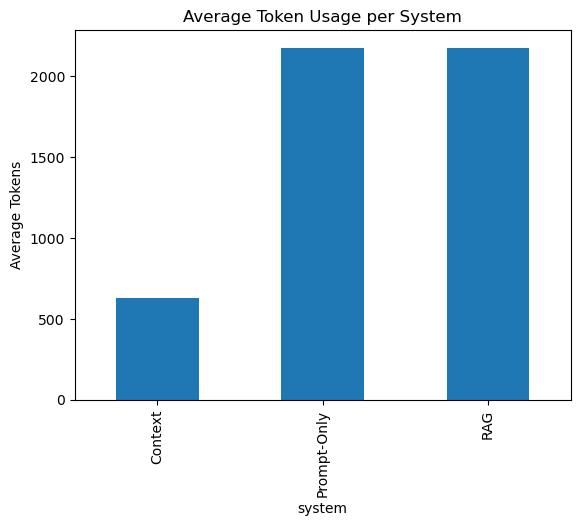

In [ ]:
# Token usage plot
summary["tokens"].plot(kind="bar")
plt.ylabel("Average Tokens")
plt.title("Average Token Usage per System")
plt.show()

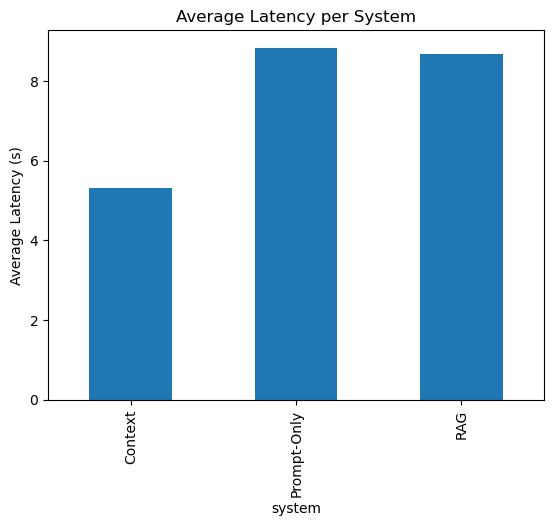

In [ ]:
# Latency Plot

summary["latency"].plot(kind="bar")
plt.ylabel("Average Latency (s)")
plt.title("Average Latency per System")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_33504\2223770422.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (summary["tokens"][i], summary["latency"][i]))


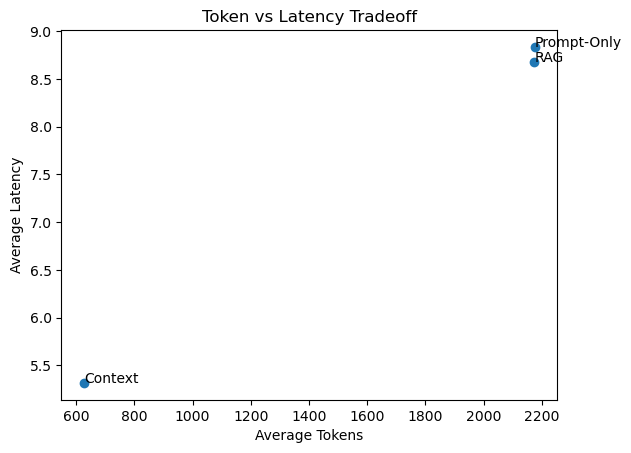

In [ ]:
# Tokens vs Latency Trageoff
plt.scatter(summary["tokens"], summary["latency"])

for i, txt in enumerate(summary.index):
    plt.annotate(txt, (summary["tokens"][i], summary["latency"][i]))

plt.xlabel("Average Tokens")
plt.ylabel("Average Latency")
plt.title("Token vs Latency Tradeoff")
plt.show()

In [ ]:
print(docs.keys())

dict_keys(['AI Act', 'DGA', 'DMA', 'DSA', 'GDPR'])
